<a href="https://colab.research.google.com/github/Samu3lNM/Projects/blob/main/Njoki_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Draft Prediction — CRISP-DM Analysis

**Goal:** Predict whether an NFL Combine athlete will be drafted (binary classification).  
**Metric:** AUC (Area Under the ROC Curve)  
**Data:** `train.csv` (2,781 rows), `test.csv` (696 rows)

---
## Phase 1: Business Understanding

### Problem Statement
NFL teams invest enormous resources selecting players in the annual Draft. From a data science perspective the task is a **binary classification** problem: given a player's physical measurements and combine performance, predict the probability they will be drafted (1 = Drafted, 0 = Not Drafted).

### Success Criteria
- Maximize AUC on the held-out test set submitted to Omnicampus.
- Predictions must be model-generated (no hand-labeling) and fully reproducible.

---
## Phase 2: Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (2781, 16)
Test shape:  (696, 15)


,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


### Feature Descriptions

| Feature | Type | Description |
|---------|------|-------------|
| Id | int | Unique player ID |
| Year | int | Combine year (2009-2019) |
| Age | float | Player age |
| School | string | College attended |
| Height | float | Height (inches) |
| Weight | float | Weight (lbs) |
| Sprint_40yd | float | 40-yard dash time (lower = faster) |
| Vertical_Jump | float | Vertical leap (inches) |
| Bench_Press_Reps | float | 225-lb bench press reps |
| Broad_Jump | float | Broad jump (inches) |
| Agility_3cone | float | 3-cone drill time (lower = better) |
| Shuttle | float | 20-yard shuttle time (lower = better) |
| Player_Type | string | offense / defense / special_teams |
| Position_Type | string | 7 categories (e.g., backs_receivers) |
| Position | string | 20 specific positions (WR, CB, RB...) |
| **Drafted** | float | **Target: 1.0 = drafted, 0.0 = not drafted** |

=== Target Distribution ===
Drafted
1.0    1803
0.0     978
Name: count, dtype: int64
Drafted
1.0    0.648
0.0    0.352
Name: proportion, dtype: float64


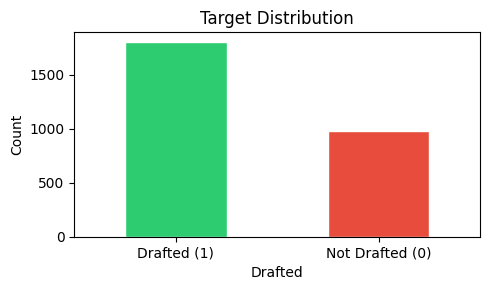

In [3]:
# Target distribution
print('=== Target Distribution ===')
print(train['Drafted'].value_counts())
print(train['Drafted'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3))
train['Drafted'].value_counts().plot(kind='bar', ax=ax,
    color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_xticklabels(['Drafted (1)', 'Not Drafted (0)'], rotation=0)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

=== Missing Values (Train) ===
                  Missing  Pct Missing
Agility_3cone         970         34.9
Shuttle               912         32.8
Bench_Press_Reps      721         25.9
Broad_Jump            581         20.9
Vertical_Jump         554         19.9
Age                   435         15.6
Sprint_40yd           145          5.2


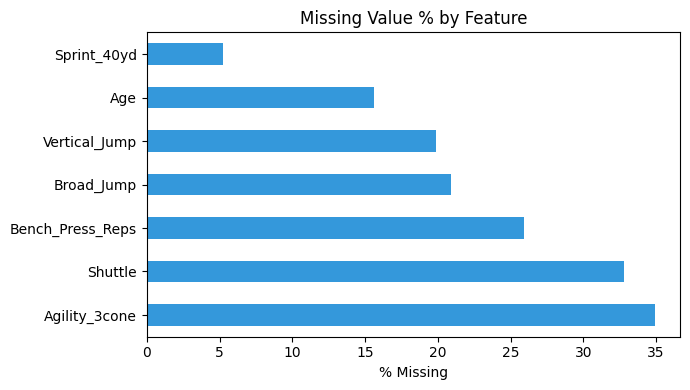

In [4]:
# Missing values
missing = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct Missing': missing_pct})
print('=== Missing Values (Train) ===')
print(missing_df[missing_df['Missing'] > 0])

fig, ax = plt.subplots(figsize=(7, 4))
missing_pct[missing_pct > 0].plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Missing Value % by Feature')
ax.set_xlabel('% Missing')
plt.tight_layout()
plt.show()

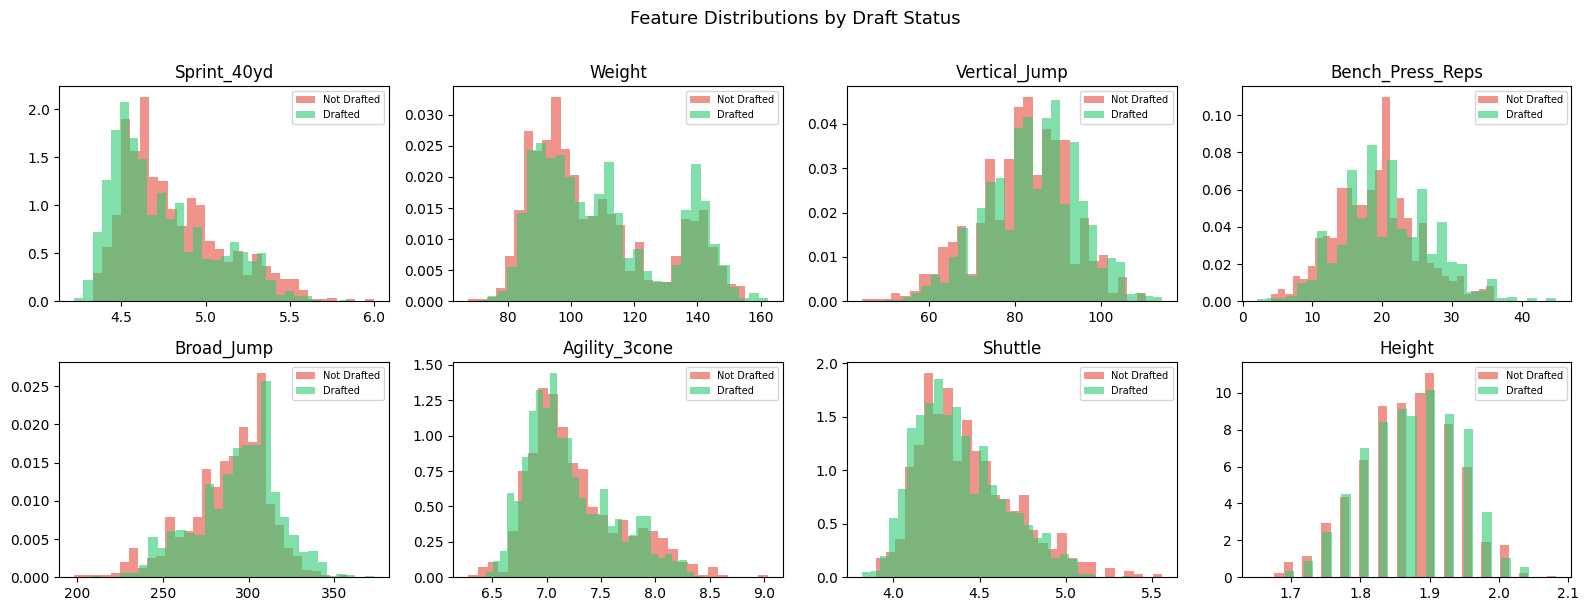

In [5]:
# Distribution of numeric features by Drafted label
num_features = ['Sprint_40yd', 'Weight', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Height']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for label, color in [(0.0, '#e74c3c'), (1.0, '#2ecc71')]:
        subset = train[train['Drafted'] == label][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color,
                     label='Drafted' if label == 1 else 'Not Drafted', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Draft Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

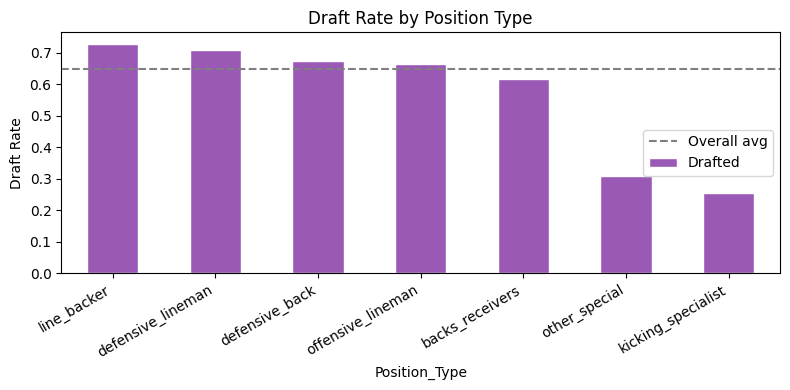

In [6]:
# Draft rate by Position_Type
draft_by_pos = train.groupby('Position_Type')['Drafted'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
draft_by_pos.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Draft Rate by Position Type')
ax.set_ylabel('Draft Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.axhline(train['Drafted'].mean(), linestyle='--', color='gray', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 3: Data Preparation

Steps applied:
1. **Categorical Encoding:** `Player_Type`, `Position_Type`, and `Position` label-encoded.
2. **Missing Value Imputation:** Numeric features filled with their **median**.
3. **Feature Dropping:** `School` (300+ unique levels) and `Id` dropped.

**Potential improvements:**
- Impute by position group instead of global median.
- Add binary indicator features for whether a drill was completed.
- Target-encode `School` using draft rate from training data.

In [7]:
from sklearn.preprocessing import LabelEncoder

def preprocess(df):
    df = df.copy()
    # Label-encode categoricals
    for col in ['Player_Type', 'Position_Type', 'Position']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    # Drop non-informative columns
    df = df.drop(columns=['School'])
    # Impute numeric NAs with median
    num_cols = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle']
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    return df

train_p = preprocess(train)
test_p  = preprocess(test)

X      = train_p.drop(columns=['Id', 'Drafted'])
y      = train_p['Drafted']
X_test = test_p.drop(columns=['Id'])

print('X shape:', X.shape)
print('X_test shape:', X_test.shape)
print('Remaining NAs in X:', X.isnull().sum().sum())

X shape: (2781, 13)
X_test shape: (696, 13)
Remaining NAs in X: 0


---
## Phase 4: Modeling

Three models compared using **5-fold stratified cross-validation**:

| Model | CV AUC |
|-------|--------|
| Logistic Regression | 0.6963 |
| Random Forest (200 trees) | 0.7280 |
| **Gradient Boosting (200 trees)** | **0.7384** |

Gradient Boosting selected as the final model.

Logistic Regression: CV AUC = 0.6918
Random Forest: CV AUC = 0.7280
Gradient Boosting: CV AUC = 0.7384


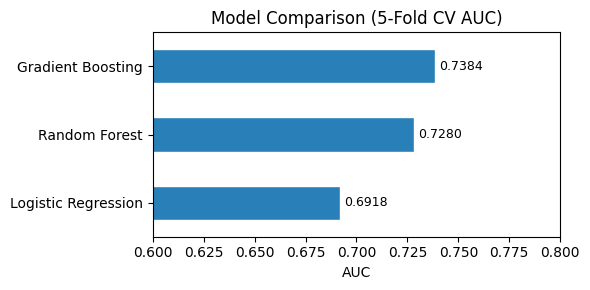

In [8]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, random_state=42),
}

results = {}
for name, model in models.items():
    auc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc').mean()
    results[name] = auc
    print(f'{name}: CV AUC = {auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
pd.Series(results).sort_values().plot(kind='barh', ax=ax, color='#2980b9', edgecolor='white')
ax.set_title('Model Comparison (5-Fold CV AUC)')
ax.set_xlabel('AUC')
ax.set_xlim(0.60, 0.80)
for i, (k, v) in enumerate(sorted(results.items(), key=lambda x: x[1])):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

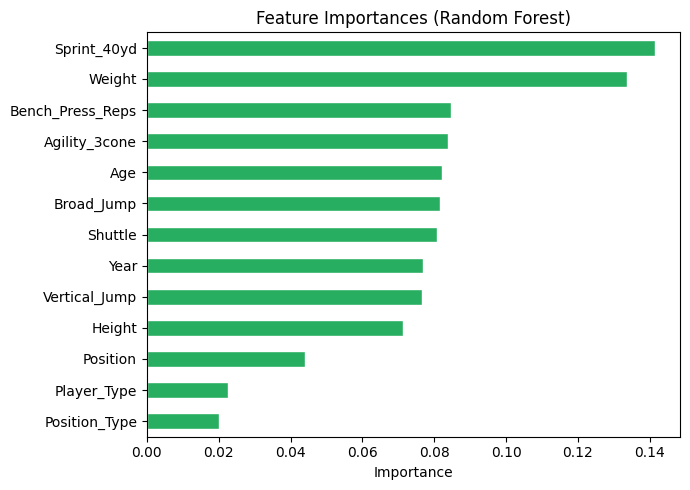

Sprint_40yd         0.141377
Weight              0.133722
Bench_Press_Reps    0.084671
Agility_3cone       0.083809
Age                 0.082314
Broad_Jump          0.081751
Shuttle             0.080920
Year                0.076782
Vertical_Jump       0.076556
Height              0.071343
Position            0.044061
Player_Type         0.022567
Position_Type       0.020127
dtype: float64


In [9]:
# Feature importance from Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
feat_imp.plot(kind='barh', ax=ax, color='#27ae60', edgecolor='white')
ax.set_title('Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(feat_imp.sort_values(ascending=False))

---
## Phase 5: Evaluation

- **Final model AUC (5-fold CV): 0.7384**
- Predictions are probability scores between 0 and 1, suitable for AUC evaluation.
- The Gradient Boosting model outperforms the logistic baseline by ~4 AUC points, confirming non-linear relationships in the data.

### Limitations
- Global median imputation may introduce bias across positions.
- `School` feature is unused; top programs may have systematically higher draft rates.
- No hyperparameter tuning was performed; further gains are likely.

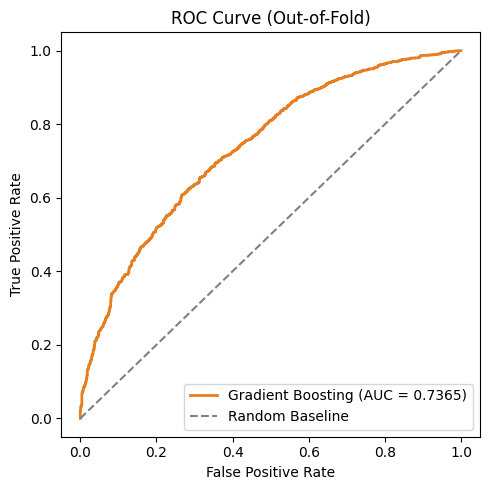

In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

gb_final = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=4, random_state=42)

# Out-of-fold probabilities for ROC plot
oof_probs = cross_val_predict(gb_final, X, y, cv=cv, method='predict_proba')[:, 1]
fpr, tpr, _ = roc_curve(y, oof_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color='#e67e22', lw=2, label=f'Gradient Boosting (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Out-of-Fold)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 6: Deployment

Generate final predictions on the test set and save to `submission.csv`.

In [11]:
import os
os.makedirs('output', exist_ok=True)

# Train final model on all training data
gb_final.fit(X, y)

# Predict probabilities on test set
preds = gb_final.predict_proba(X_test)[:, 1]

# Build submission
submission = pd.DataFrame({'Id': test['Id'], 'Drafted': preds})
submission.to_csv('output/submission.csv', index=False)

print('Submission saved to output/submission.csv')
print(f'Shape: {submission.shape}')
submission.head(10)

Submission saved to output/submission.csv
Shape: (696, 2)


,Id,Drafted
0,2781,0.180272
1,2782,0.769556
2,2783,0.909606
3,2784,0.908062
4,2785,0.750810
5,2786,0.441846
6,2787,0.580422
7,2788,0.594561
8,2789,0.592068
9,2790,0.797235


---
## How to Improve Further

1. **Hyperparameter tuning** - Use `GridSearchCV` or `optuna` on GBM parameters (`max_depth`, `learning_rate`, `subsample`).
2. **XGBoost / LightGBM** - Typically outperform sklearn's GBM on tabular data.
3. **Position-aware imputation** - Impute each numeric feature using the median within that position group.
4. **School encoding** - Compute draft rate per school on training data; use as a numeric feature.
5. **Missing indicator features** - Add binary columns (e.g., `has_agility_3cone`) to capture whether a drill was skipped.
6. **Ensemble stacking** - Blend predictions from multiple models for robustness.

---
*All random states set to `42` for reproducibility. No manual predictions used.*